In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("Energy_Dataset_ML.csv")
data.head()

,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,target
0,04/10/2024 12:00,0.0,0.0,0.0,119.290878,0.0,0.0,108.502075,134.461426,100.306824,...,101.537338,526.225403,950.598267,317.534698,87.328026,908.293213,831.583679,1493.268188,728.515625,1522.5
1,04/10/2024 12:15,0.0,0.0,0.0,119.224632,0.0,0.0,0.173611,0.404006,0.115741,...,87.574669,512.467468,924.710449,219.791656,85.734978,44.133453,21.282021,0.000000,776.747009,1895.0
2,04/10/2024 12:30,0.0,0.0,0.0,119.294258,0.0,0.0,100.112236,109.554970,0.115741,...,67.657333,523.296082,923.986328,158.854156,88.341782,35.701073,644.438171,0.000000,748.914978,2572.5
3,04/10/2024 12:45,0.0,0.0,0.0,119.451820,0.0,0.0,95.328934,137.838760,70.482636,...,94.453339,543.406433,937.504272,179.861099,85.807388,280.516205,726.837707,0.000000,775.173645,2652.5
4,04/10/2024 13:00,0.0,0.0,0.0,119.407585,0.0,0.0,85.291878,144.616455,90.254265,...,96.096001,540.641663,949.533142,278.645813,84.866043,848.549438,815.185974,1540.173706,789.008301,2650.0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40952 entries, 0 to 40951
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time        40952 non-null  str    
 1   feature_01  40952 non-null  float64
 2   feature_02  40952 non-null  float64
 3   feature_03  40952 non-null  float64
 4   feature_04  40952 non-null  float64
 5   feature_05  40952 non-null  float64
 6   feature_06  40952 non-null  float64
 7   feature_07  40952 non-null  float64
 8   feature_08  40952 non-null  float64
 9   feature_09  40952 non-null  float64
 10  feature_10  40952 non-null  float64
 11  feature_11  40952 non-null  float64
 12  feature_12  40952 non-null  float64
 13  feature_13  40952 non-null  float64
 14  feature_14  40952 non-null  float64
 15  feature_15  40952 non-null  float64
 16  feature_16  40952 non-null  float64
 17  feature_17  40952 non-null  float64
 18  feature_18  40952 non-null  float64
 19  feature_19  40952 non-null  float64


In [5]:
data['Time'] = pd.to_datetime(data['Time'])

In [6]:
# Take only first 10 days data
filtered_data = data[
    data["Time"] <= data["Time"].min() + pd.Timedelta(days=7)
]

# Feature columns
feature_cols = [col for col in data.columns if col.startswith("feature_")]
print(feature_cols)

['feature_01', 'feature_02', 'feature_03', 'feature_04', 'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21']


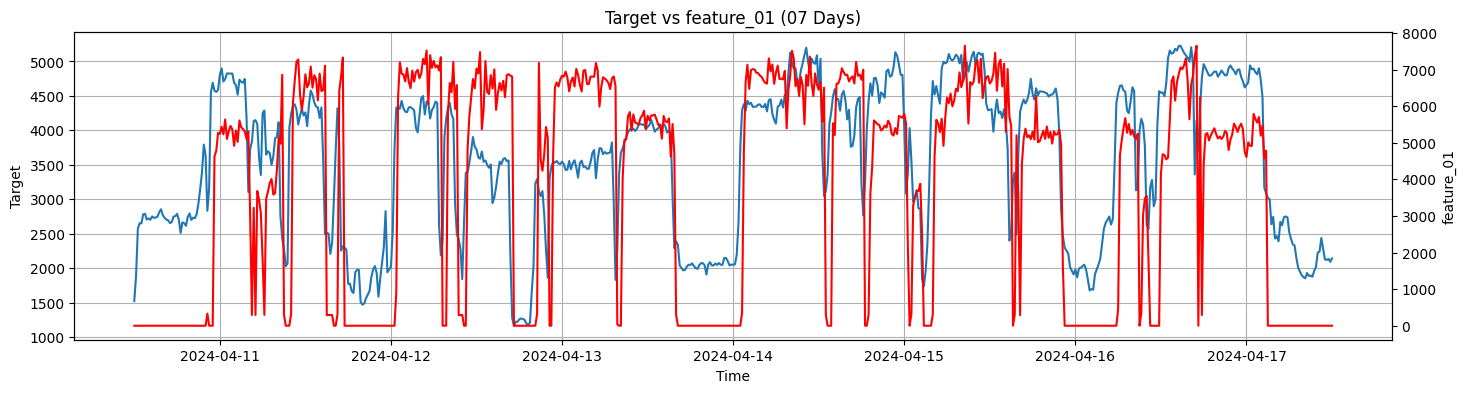

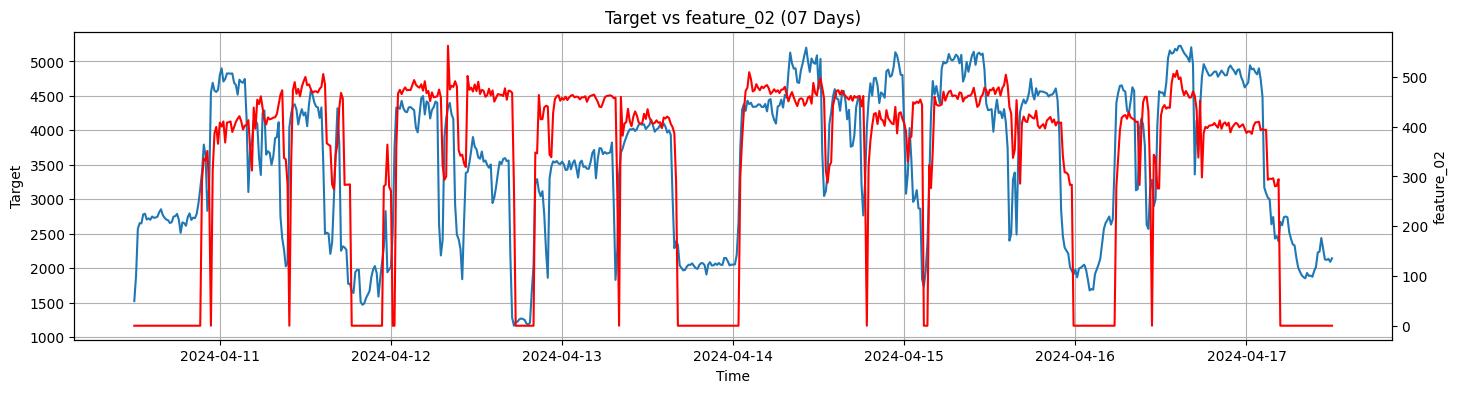

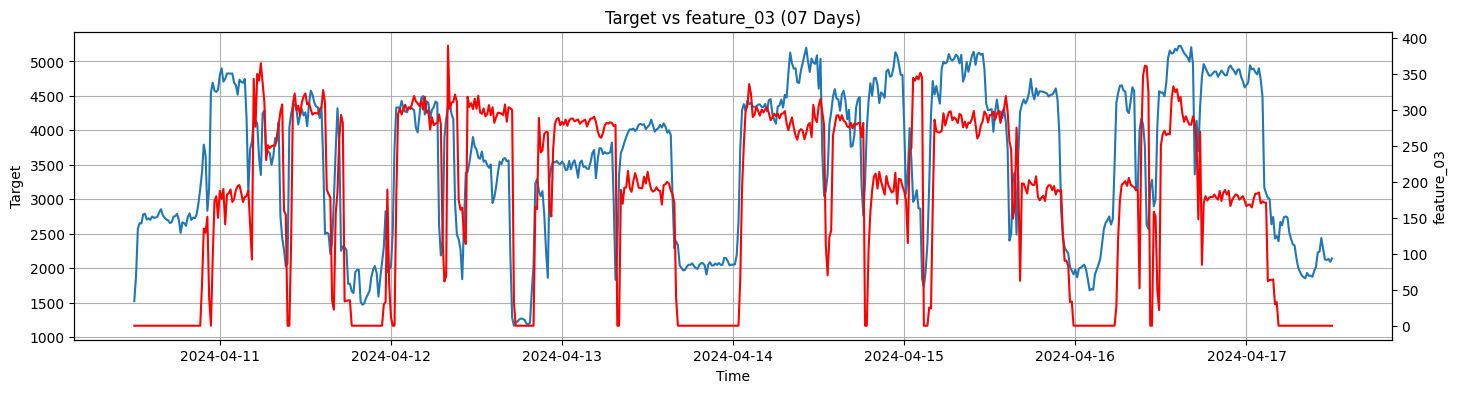

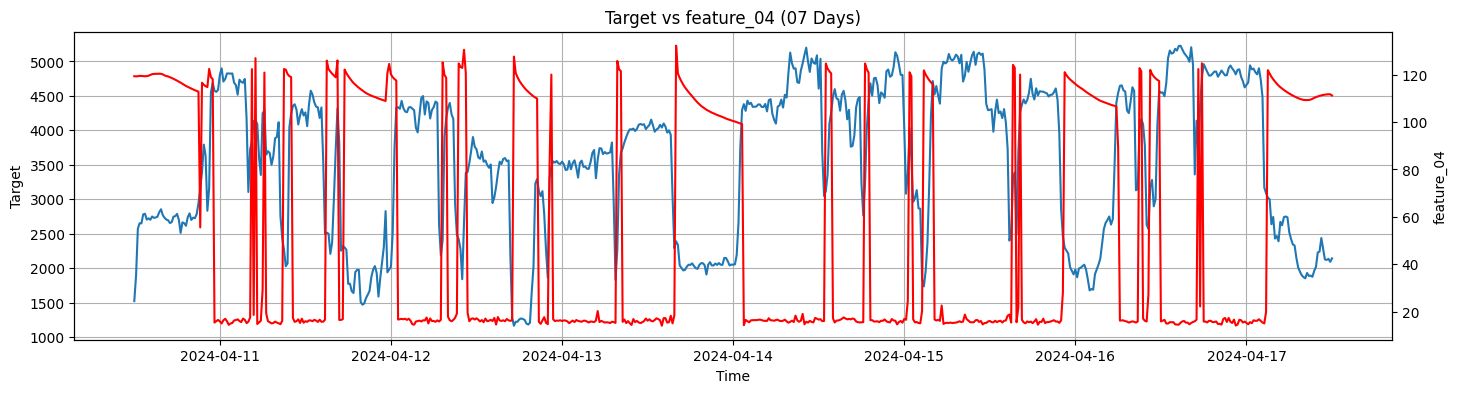

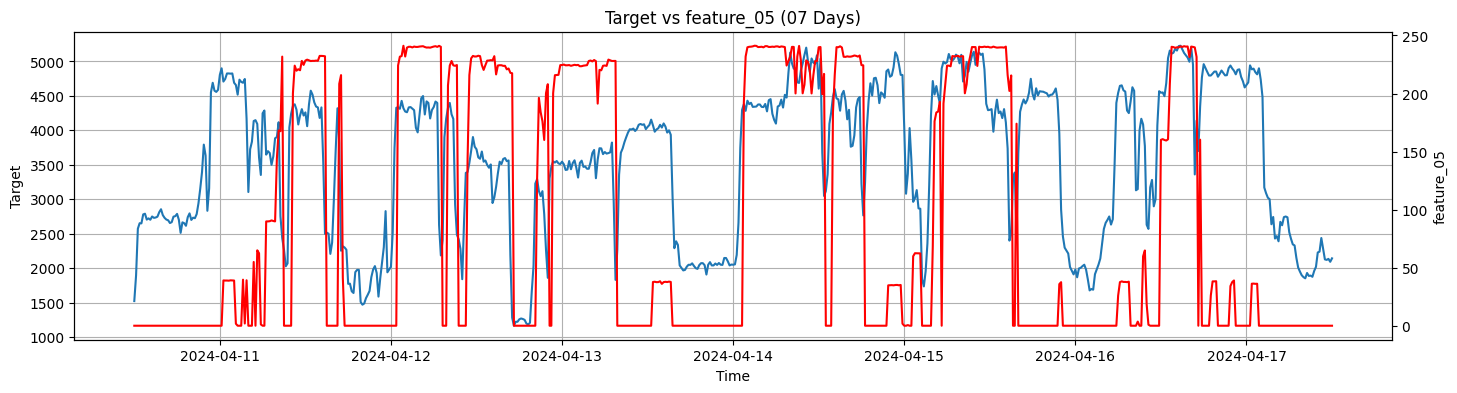

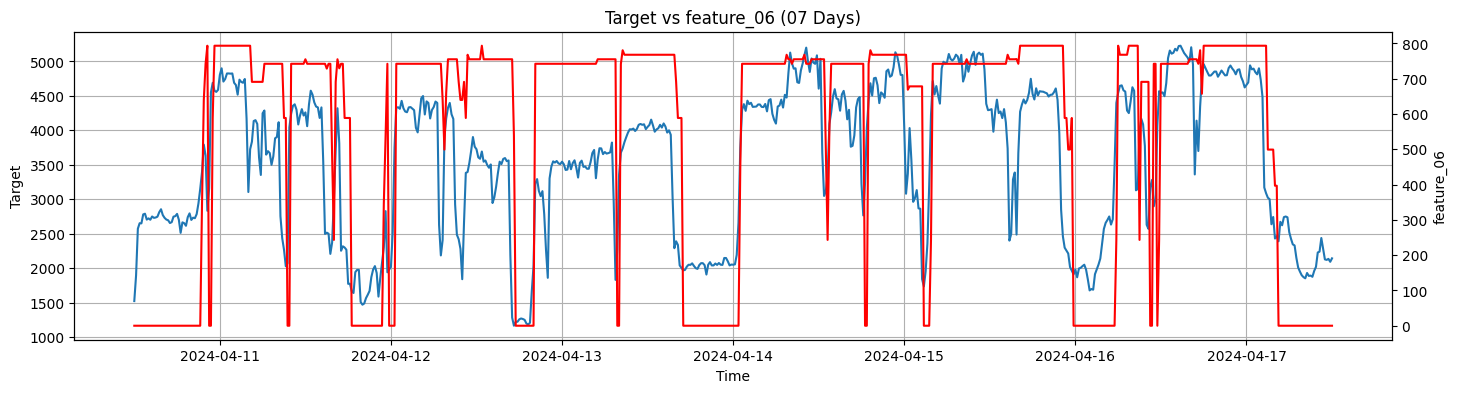

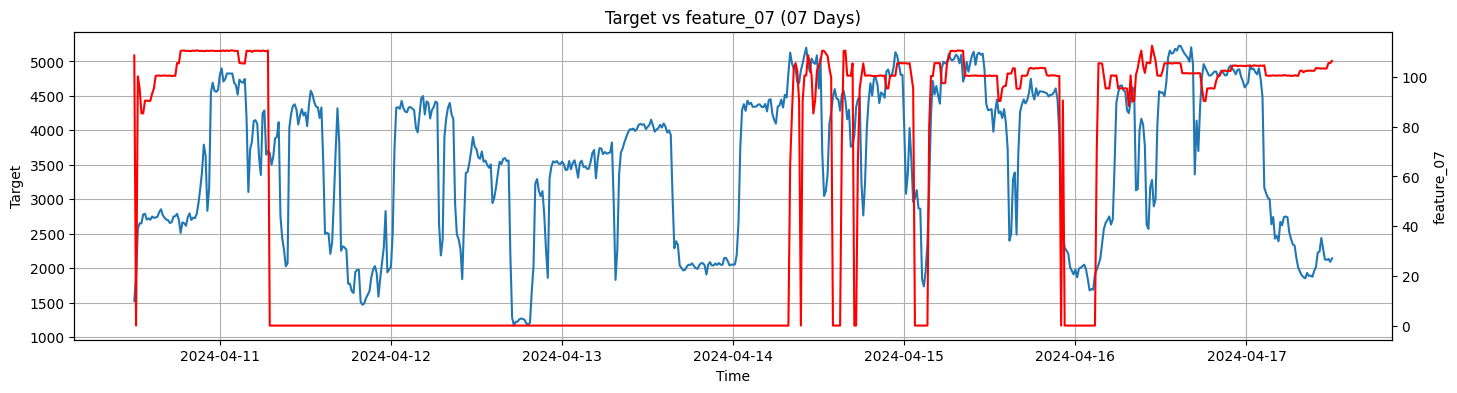

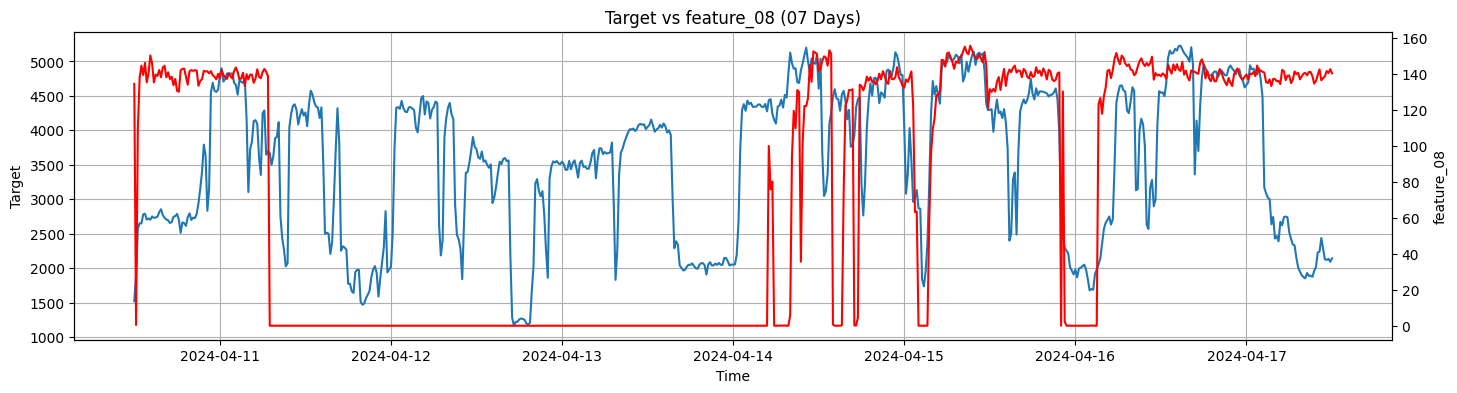

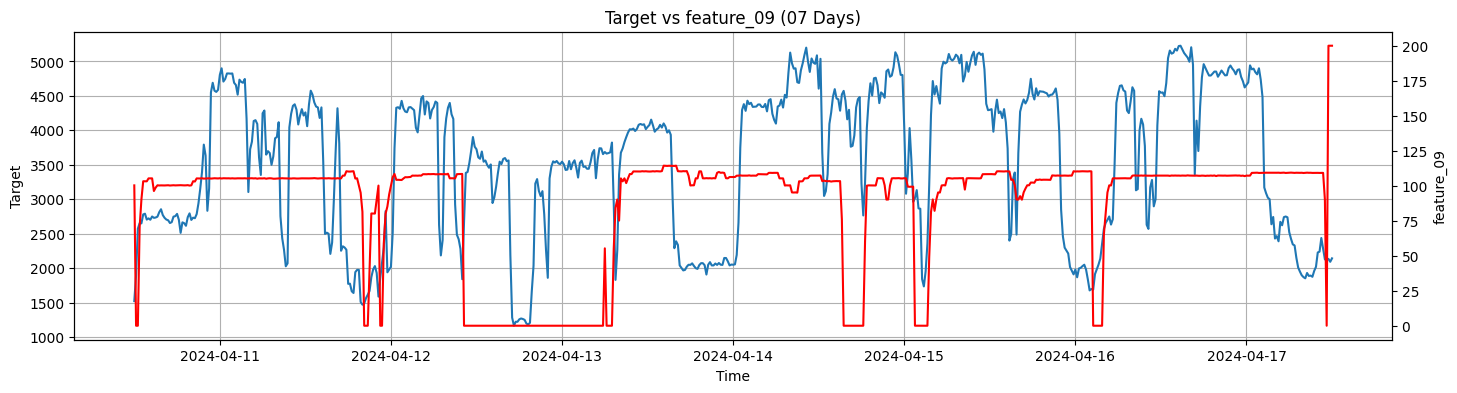

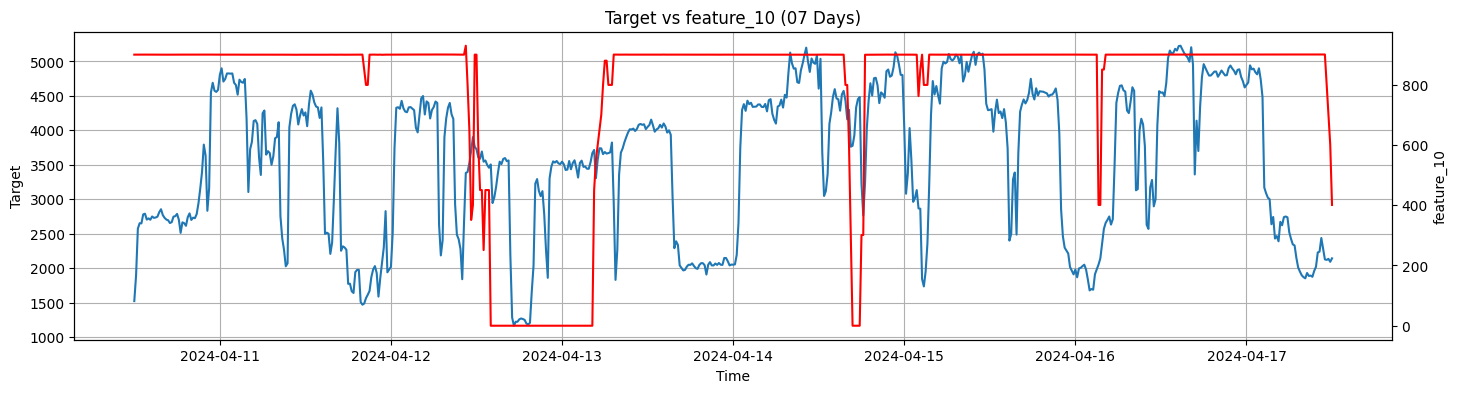

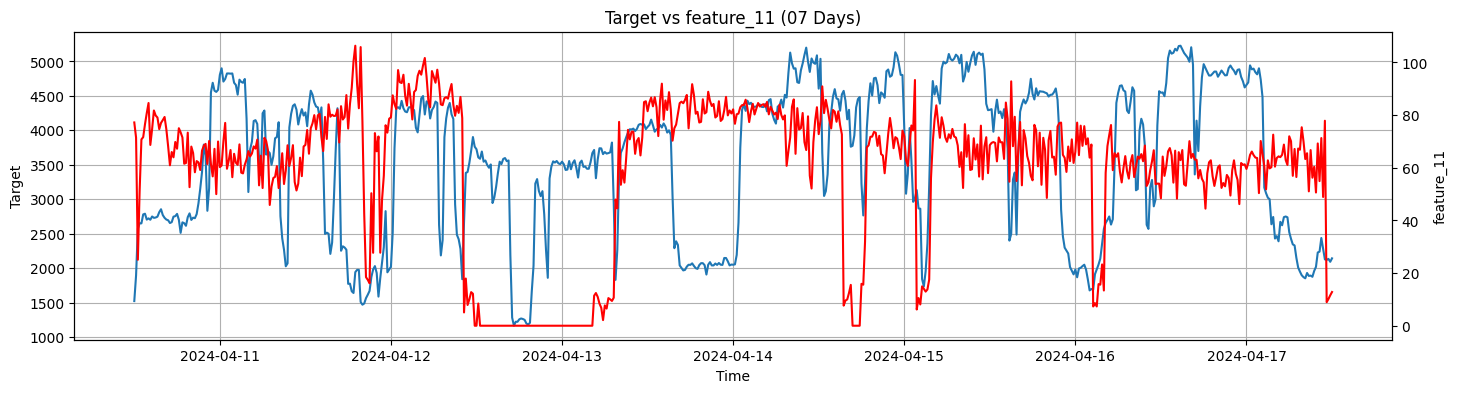

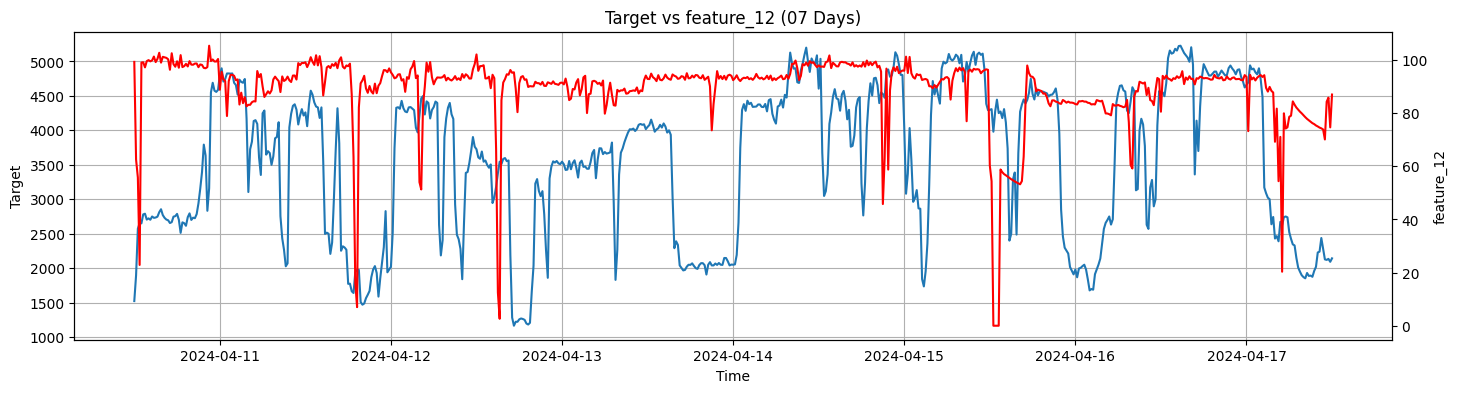

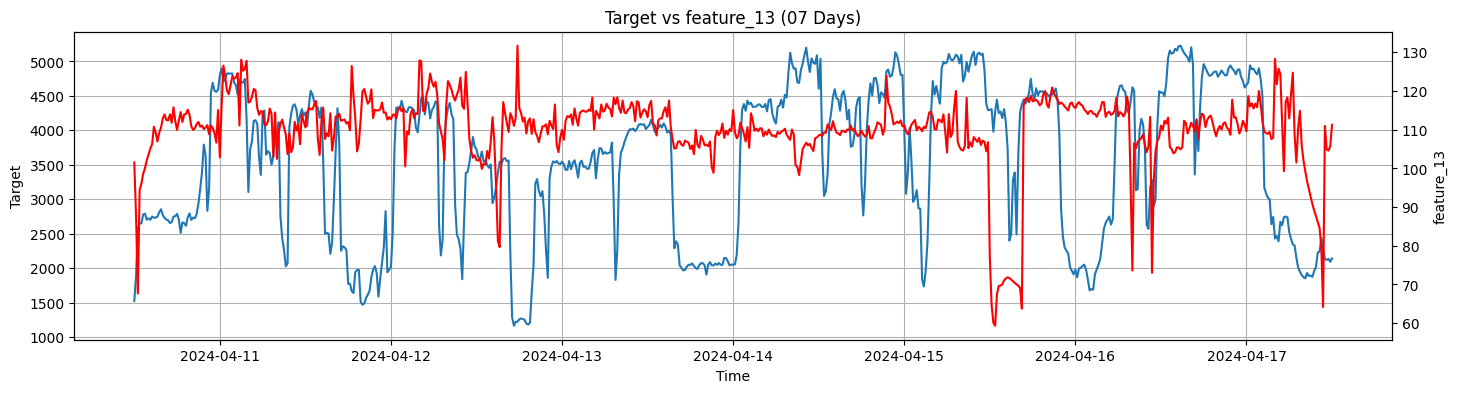

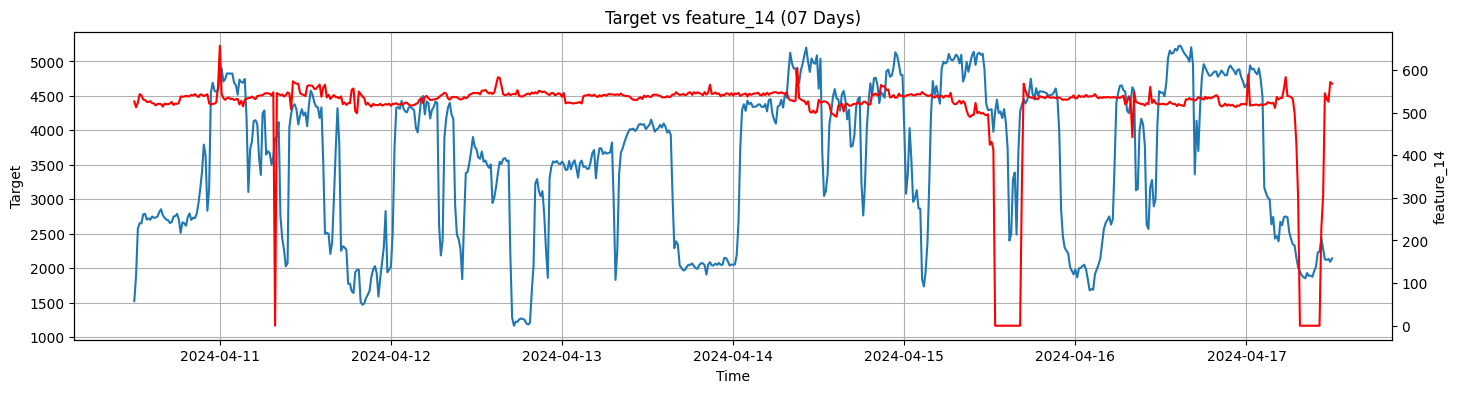

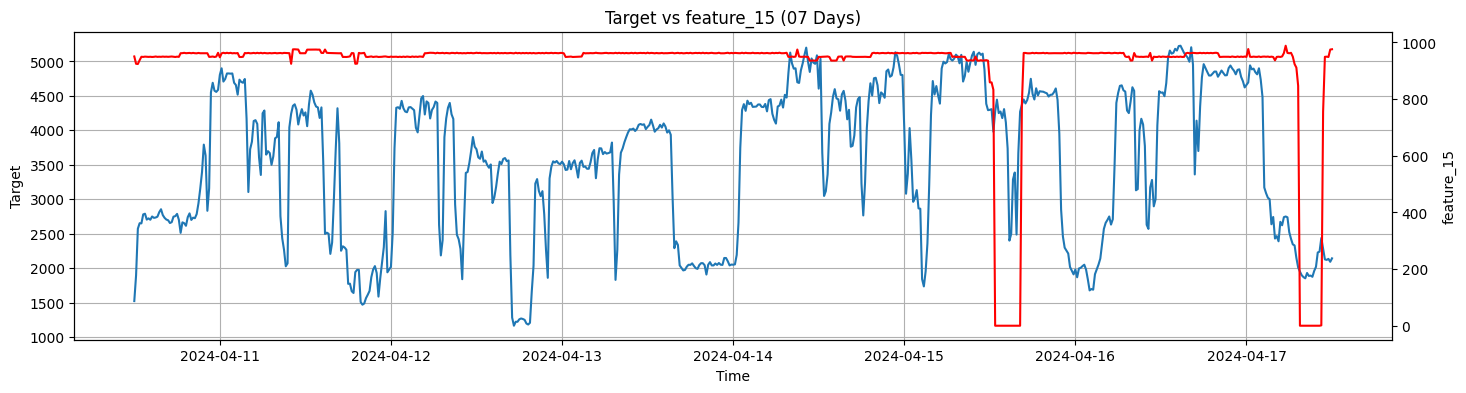

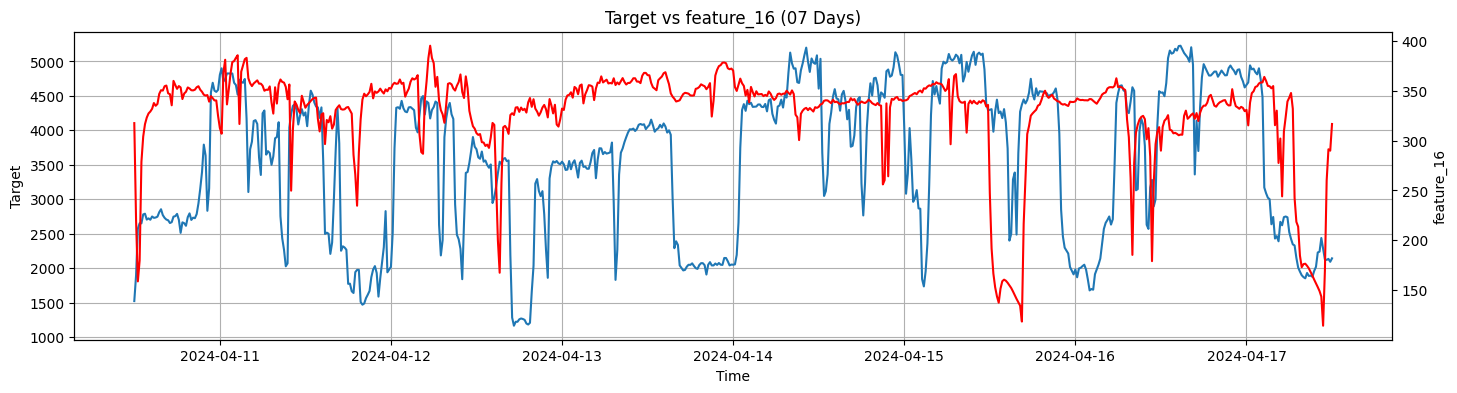

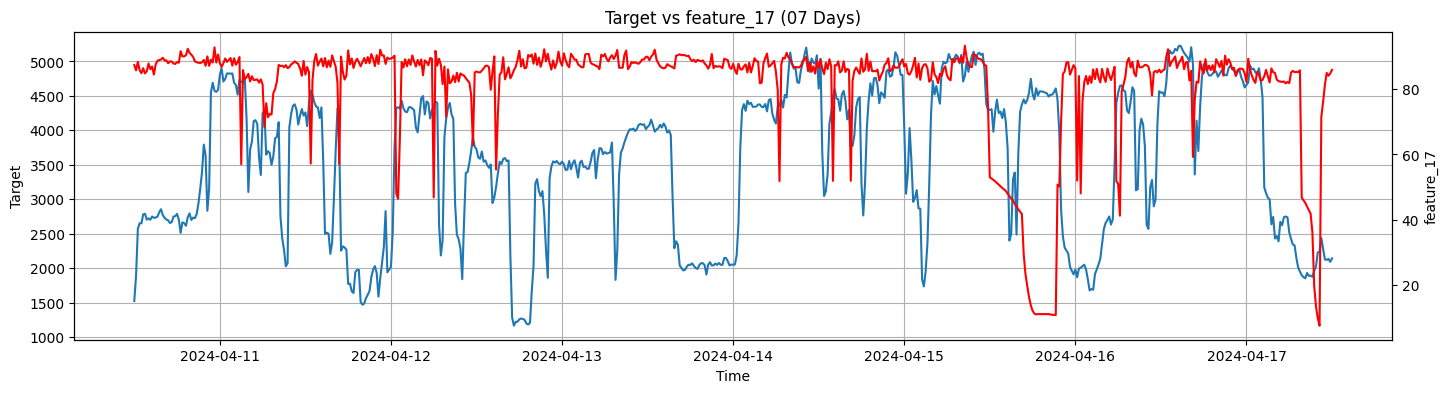

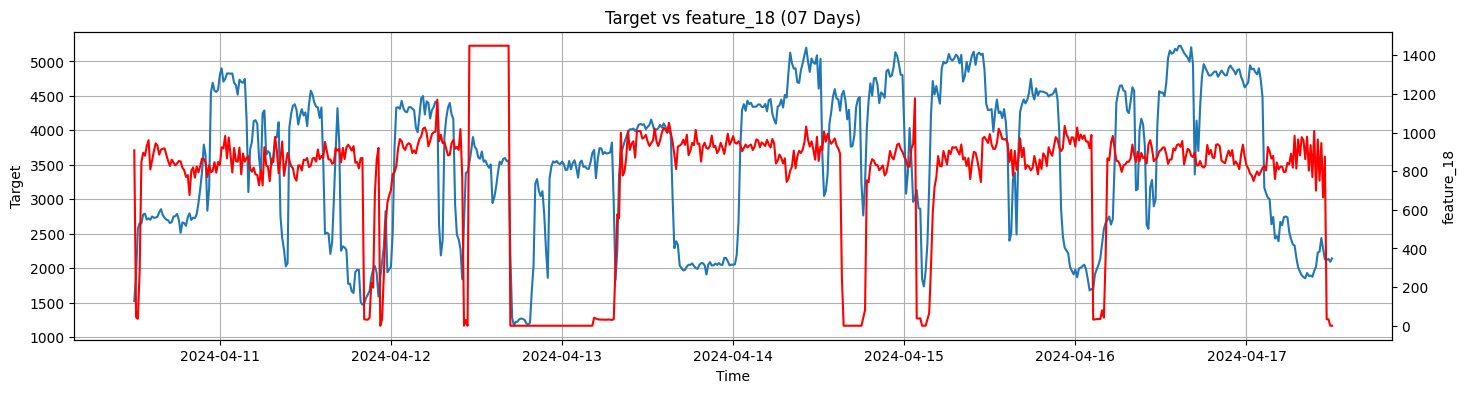

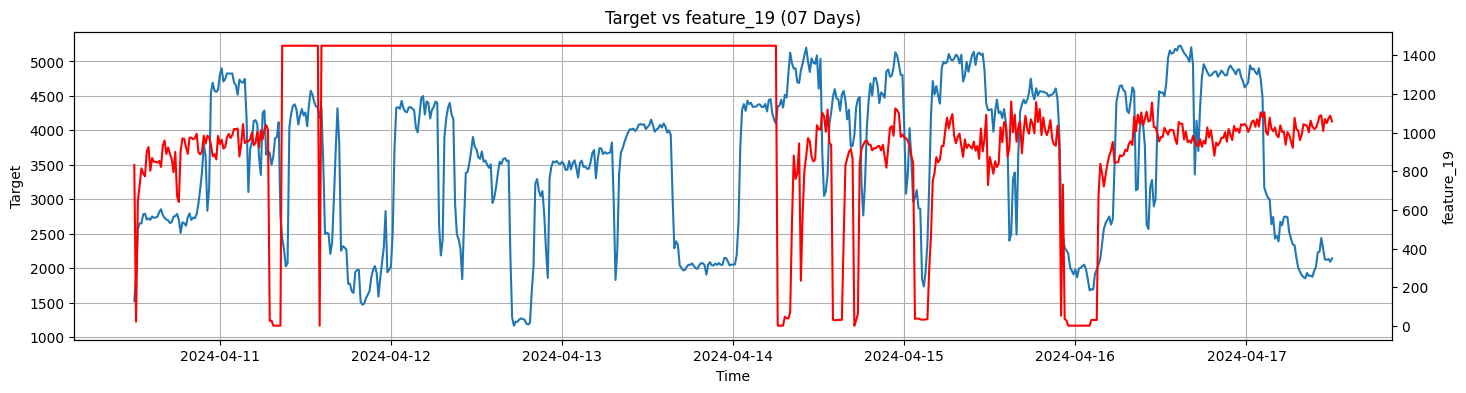

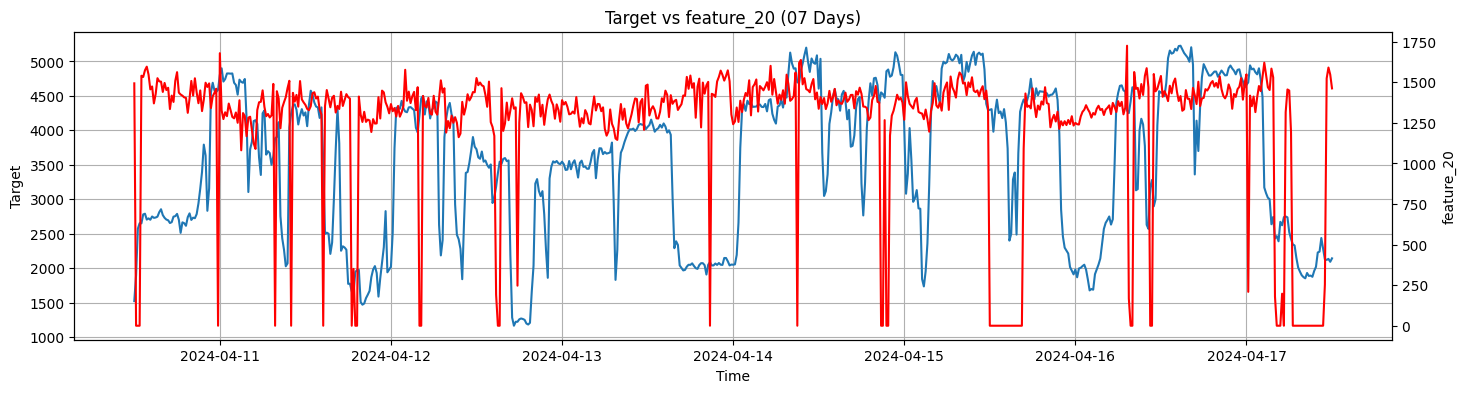

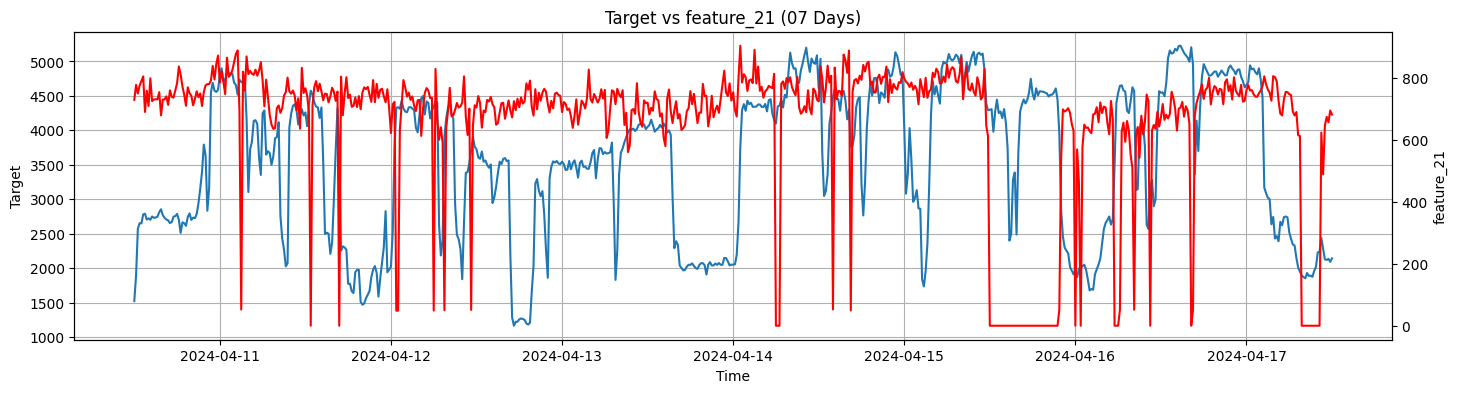

In [7]:


# Plot each feature with target
for feature in feature_cols:
    fig, ax1 = plt.subplots(figsize=(17,4))
    
    # LEFT AXIS -> TARGET
    ax1.plot(filtered_data["Time"],filtered_data["target"],label="target")
    
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Target")
    ax1.tick_params(axis='y')
    
    # RIGHT AXIS -> FEATURE
    ax2 = ax1.twinx()
    ax2.plot(filtered_data["Time"],filtered_data[feature],label=feature, color ="red")
    ax2.set_ylabel(feature)
    ax2.tick_params(axis='y')
    
    # Title
    plt.title(f"Target vs {feature} (07 Days)")
    
    # Grid
    ax1.grid(True)
    
    plt.show()

In [8]:
data[["feature_01", "target"]].corr()

,feature_01,target
feature_01,1.000000,0.753444
target,0.753444,1.000000


In [9]:
data["target_diff"] = data["target"].diff()

In [18]:
data.head()

,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,target,target_diff
0,2024-04-10 12:00:00,0.0,0.0,0.0,119.290878,0.0,0.0,108.502075,134.461426,100.306824,...,526.225403,950.598267,317.534698,87.328026,908.293213,831.583679,1493.268188,728.515625,1522.5,NaN
1,2024-04-10 12:15:00,0.0,0.0,0.0,119.224632,0.0,0.0,0.173611,0.404006,0.115741,...,512.467468,924.710449,219.791656,85.734978,44.133453,21.282021,0.000000,776.747009,1895.0,372.5
2,2024-04-10 12:30:00,0.0,0.0,0.0,119.294258,0.0,0.0,100.112236,109.554970,0.115741,...,523.296082,923.986328,158.854156,88.341782,35.701073,644.438171,0.000000,748.914978,2572.5,677.5
3,2024-04-10 12:45:00,0.0,0.0,0.0,119.451820,0.0,0.0,95.328934,137.838760,70.482636,...,543.406433,937.504272,179.861099,85.807388,280.516205,726.837707,0.000000,775.173645,2652.5,80.0
4,2024-04-10 13:00:00,0.0,0.0,0.0,119.407585,0.0,0.0,85.291878,144.616455,90.254265,...,540.641663,949.533142,278.645813,84.866043,848.549438,815.185974,1540.173706,789.008301,2650.0,-2.5


In [10]:
# Take only first 10 days data
filtered_data_diff = data[
    data["Time"] <= data["Time"].min() + pd.Timedelta(days=7)
]

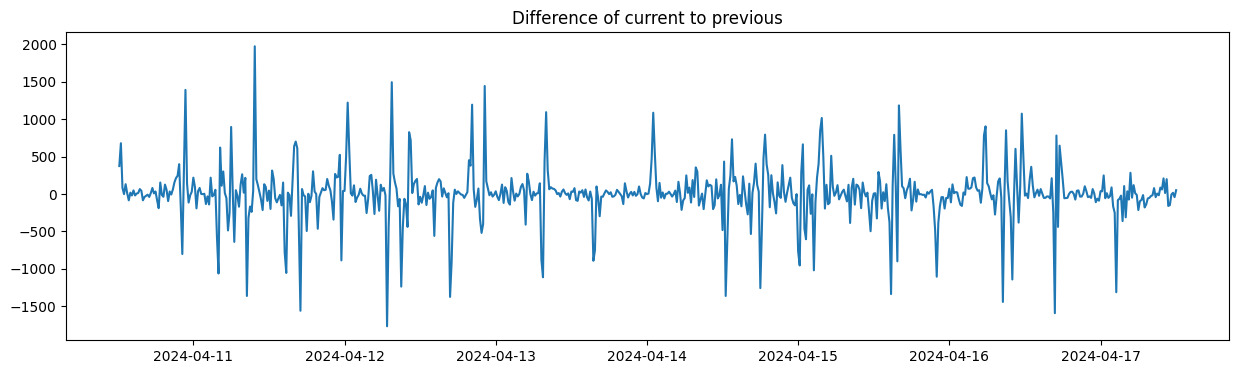

In [11]:
plt.figure(figsize=(15,4))
plt.plot(filtered_data_diff['Time'],filtered_data_diff['target_diff'])
plt.title("Difference of current to previous")
plt.show()

In [12]:
data.describe()

,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,target,target_diff
count,40952,40952.000000,40952.000000,40952.000000,40952.000000,40952.000000,40952.000000,40952.000000,40952.000000,40952.000000,...,40952.000000,40952.000000,40952.000000,40952.000000,40952.000000,40952.000000,40952.000000,40952.000000,40952.000000,40951.000000
mean,2024-12-04 04:49:28.887966,3902.156877,296.077828,152.886518,64.260022,120.809209,511.819294,76.340845,93.026896,86.606632,...,379.345566,712.610061,236.908434,74.238485,758.020621,685.872170,1026.871981,619.836987,3541.889223,0.065969
min,2024-04-10 12:00:00,0.000000,0.000000,0.000000,0.010820,0.000000,0.000000,0.115741,0.000000,0.096078,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.183481,0.000000,0.000000,0.000000,-5042.500000
25%,2024-07-27 05:11:15,0.000000,0.000000,0.000000,16.053831,0.000000,0.000000,75.317356,53.427717,95.215353,...,446.080383,885.229736,186.241310,74.493120,774.401031,666.905411,0.000000,58.865021,2552.500000,-65.000000
50%,2024-12-14 12:52:30,5230.995606,405.170288,191.872559,80.515156,59.266491,729.599976,96.166355,118.309258,105.227501,...,475.801514,912.611176,261.805542,82.693703,871.448761,799.803711,1378.175903,791.395447,3825.000000,5.000000
75%,2025-03-31 09:03:45,7016.287231,439.703980,240.944824,110.621801,244.118912,742.400024,102.415964,134.888348,110.339472,...,491.040588,925.400818,290.451386,87.183205,935.642929,875.816071,1469.055298,863.769531,4685.000000,90.000000
max,2025-07-31 23:00:00,7960.601074,710.868530,559.914551,135.429352,300.000000,934.349976,200.000000,157.527710,200.000000,...,910.000000,989.399658,600.000000,181.607544,1450.000000,1450.000000,2298.371338,1179.958862,5460.000000,5248.000000
std,NaN,3273.622302,195.739376,116.615331,47.732196,119.596579,333.285731,44.186931,55.513266,42.391359,...,198.599246,386.513260,95.822208,21.824856,355.851047,379.882563,646.455305,365.584084,1271.463994,390.212352


In [13]:
#Time feature analysis

data['hour'] = data['Time'].dt.hour
data['day'] = data['Time'].dt.day
data['month'] = data['Time'].dt.month
data['day_of_week'] = data['Time'].dt.dayofweek
data['is_weekend'] = (data['day_of_week'].isin([5,6]).astype(int))


data.head()


,Time,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_19,feature_20,feature_21,target,target_diff,hour,day,month,day_of_week,is_weekend
0,2024-04-10 12:00:00,0.0,0.0,0.0,119.290878,0.0,0.0,108.502075,134.461426,100.306824,...,831.583679,1493.268188,728.515625,1522.5,NaN,12,10,4,2,0
1,2024-04-10 12:15:00,0.0,0.0,0.0,119.224632,0.0,0.0,0.173611,0.404006,0.115741,...,21.282021,0.000000,776.747009,1895.0,372.5,12,10,4,2,0
2,2024-04-10 12:30:00,0.0,0.0,0.0,119.294258,0.0,0.0,100.112236,109.554970,0.115741,...,644.438171,0.000000,748.914978,2572.5,677.5,12,10,4,2,0
3,2024-04-10 12:45:00,0.0,0.0,0.0,119.451820,0.0,0.0,95.328934,137.838760,70.482636,...,726.837707,0.000000,775.173645,2652.5,80.0,12,10,4,2,0
4,2024-04-10 13:00:00,0.0,0.0,0.0,119.407585,0.0,0.0,85.291878,144.616455,90.254265,...,815.185974,1540.173706,789.008301,2650.0,-2.5,13,10,4,2,0


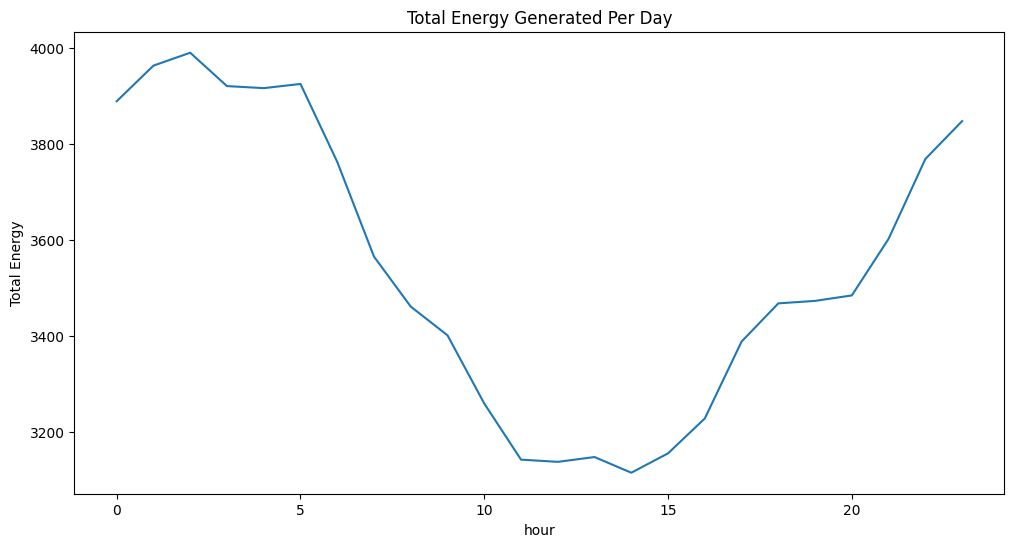

In [ ]:
plt.figure(figsize=(12,6))
day_energy = data.groupby('hour')['target'].mean()

day_energy.plot(kind='line',)

plt.xlabel("hour")
plt.ylabel("Total Energy")
plt.title("Total Energy Generated Per Day")

plt.show()